In [1]:
import pandas as pd

In [3]:
df_other = pd.read_excel("/lustre/groups/ml01/workspace/ot_perturbation/data/norman_2/cellflow_l2/perturbation_prediction.xlsx", index_col=0)

In [61]:
df_other.index.unique()

Index(['norman_from_scfoundation'], dtype='object', name='dataset_name')

In [4]:
df_other.head()

,seed,method,perturbation,train,r2,r2_delta,l2,approach,label,highlight
dataset_name,,,,,,,,,,
norman_from_scfoundation,1,scgpt,AHR+FEV,test,0.968335,0.397926,7.403043,foundation_model,scGPT|Foundation Models,False
norman_from_scfoundation,1,scgpt,AHR+KLF1,val,0.989225,0.118235,4.764357,foundation_model,scGPT|Foundation Models,False
norman_from_scfoundation,1,scgpt,BCL2L11+TGFBR2,val,0.996999,0.216117,2.651429,foundation_model,scGPT|Foundation Models,False
norman_from_scfoundation,1,scgpt,BPGM+ZBTB1,test,0.991297,0.614374,3.829740,foundation_model,scGPT|Foundation Models,False
norman_from_scfoundation,1,scgpt,CBL+CNN1,test,0.980868,0.671647,6.443645,foundation_model,scGPT|Foundation Models,False


In [15]:
df_0 = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/norman_2/cellflow_l2/l2_split_0.csv", index_col=0)
df_1 = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/norman_2/cellflow_l2/l2_split_1.csv", index_col=0)
df_2 = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/norman_2/cellflow_l2/l2_split_2.csv", index_col=0)
df_3 = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/norman_2/cellflow_l2/l2_split_3.csv", index_col=0)
df_4 = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/norman_2/cellflow_l2/l2_split_4.csv", index_col=0)

In [21]:
df_cf = pd.concat((df_0,df_1,df_2,df_3,df_4))

In [22]:
df_cf["perturbation"] = df_cf.index

In [84]:
df_cf = df_cf[df_cf["subgroup"]=="double_seen_2"]

In [85]:
len(df_cf)

64

In [112]:
df_other = df_other[df_other["perturbation"].isin(list(df_cf["perturbation"]))]

In [113]:
len(df_other)

1017

In [114]:
perts_in_other = list(df_other[df_other["train"] == "test"]["perturbation"].values)

In [115]:
perts_inter = set(df_cf["perturbation"].values).intersection(set(perts_in_other))

In [131]:
df_cf_red = df_cf[df_cf["perturbation"].isin(perts_inter)]

In [132]:
df_other_red.shape

(549, 10)

In [133]:
df_other_red = df_other[(df_other["perturbation"].isin(perts_inter)) & (df_other["train"]=="test")]

In [134]:
df_other_red = df_other_red.drop_duplicates(subset=["perturbation", "method"])

In [135]:
df_cf_red["l2"] = df_cf_red["0"]
df_cf_red["method"] = "cellflow"

/tmp/ipykernel_1851661/1433649543.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cf_red["l2"] = df_cf_red["0"]
/tmp/ipykernel_1851661/1433649543.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cf_red["method"] = "cellflow"


In [151]:
df_cf_red = df_cf_red.drop_duplicates(subset=["perturbation"])

In [152]:
len(df_cf_red)

40

In [153]:
df_both = pd.concat((df_cf_red, df_other_red))

In [154]:
df_both.groupby("method").count()

,0,subgroup,perturbation,l2,seed,train,r2,r2_delta,approach,label,highlight
method,,,,,,,,,,,
additive_model,0,0,40,40,40,40,40,40,40,40,40
cellflow,40,40,40,40,0,0,0,0,0,0,0
cpa,0,0,40,40,40,40,40,40,40,40,40
gears,0,0,40,40,40,40,40,40,40,40,40
geneformer,0,0,40,40,40,40,40,40,40,40,40
no_change,0,0,40,40,40,40,40,0,40,40,40
scbert,0,0,40,40,40,40,40,40,40,40,40
scfoundation,0,0,40,40,40,40,40,40,40,40,40
scgpt,0,0,40,40,40,40,40,40,40,40,40


In [155]:
df_both.groupby("method")["l2"].mean()

method
additive_model     2.764271
cellflow           3.098345
cpa               12.660385
gears              4.300713
geneformer         3.485052
no_change          6.317062
scbert             4.646501
scfoundation       4.977857
scgpt              5.024785
uce                4.646594
Name: l2, dtype: float64

In [156]:
1

1

In [157]:
import seaborn as sns

<Axes: xlabel='method', ylabel='l2'>

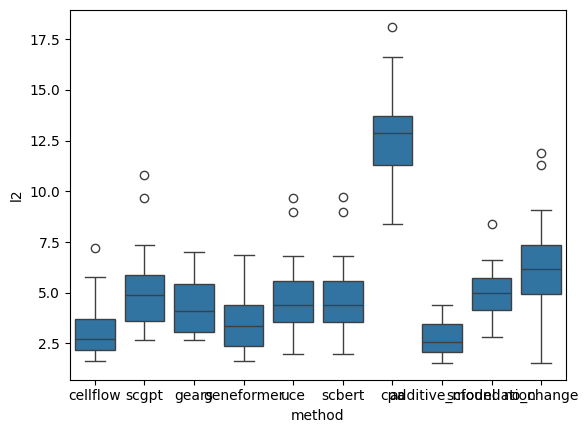

In [158]:
sns.boxplot(df_both, x="method", y="l2")

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute mean l2 per method and sort
order = df_both.groupby("method")["l2"].mean().sort_values().index

# Plot with ordered x-axis
plt.figure(figsize=(8,5))
sns.boxplot(df_both, x="method", y="l2", order=order)

# Rotate x-axis labels
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
1

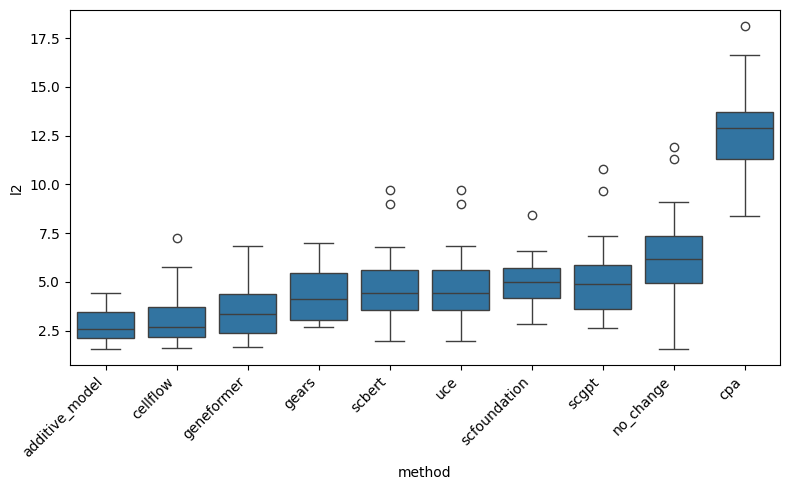

In [160]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute mean l2 per method and sort
order = df_both.groupby("method")["l2"].mean().sort_values().index

# Plot with ordered x-axis
plt.figure(figsize=(8,5))
sns.boxplot(df_both, x="method", y="l2", order=order)

# Rotate x-axis labels
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
